# Handwritten Digit Recognition with a CNN (MNIST, PyTorch)

This notebook trains a small Convolutional Neural Network (CNN) on the MNIST dataset and then uses it to
classify real handwritten digits photographed or drawn by hand (see the `samples/` folder).

**Steps**
1. Setup (imports, device, random seed)
2. Data loading with augmentation
3. Model definition
4. Training and evaluation
5. Saving / loading the trained weights
6. Predicting your own handwritten digits

## 1. Setup

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageOps
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
torch.manual_seed(SEED)

# Pick the best available device: NVIDIA GPU, Apple Silicon GPU, or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Hyperparameters and paths
BATCH_SIZE = 64
LEARNING_RATE = 0.003
EPOCHS = 3
MODEL_PATH = "cnn_mnist_model.pt"
SAMPLES_DIR = "samples"

# MNIST mean and standard deviation, used for normalisation
MNIST_MEAN, MNIST_STD = (0.1307,), (0.3081,)

Using device: mps


## 2. Data

The training set is augmented with small random rotations, shifts and scaling so the model copes better
with messy, off-centre real-world handwriting. The test set is only normalised.

In [2]:
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

train_data = datasets.MNIST(root="data", train=True, download=True, transform=train_transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000)

print(f"Training images: {len(train_data)} | Test images: {len(test_data)}")

Training images: 60000 | Test images: 10000


## 3. Model

Two convolution + max-pooling blocks followed by two fully connected layers.
Input: 1 × 28 × 28 grayscale image → output: 10 class scores (digits 0–9).

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            # MNIST images are 1 channel, 28x28
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 32 x 14 x 14

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 64 x 7 x 7

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.layers(x)


model = Net().to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Net(
  (layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 421,642


## 4. Training and evaluation

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train(epoch):
    model.train()
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()            # reset gradients
        outputs = model(images)          # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                  # backward pass (autograd computes gradients)
        optimizer.step()                 # update weights

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch} [{batch_idx * len(images)}/{len(train_data)}] "
                  f"loss: {loss.item():.4f}")


def test():
    model.eval()
    correct = 0
    with torch.no_grad():                # no gradients needed for evaluation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images).argmax(dim=1)
            correct += (predictions == labels).sum().item()
    accuracy = 100.0 * correct / len(test_data)
    print(f"Test accuracy: {accuracy:.2f}%\n")
    return accuracy

In [5]:
for epoch in range(1, EPOCHS + 1):
    train(epoch)
    test()

Epoch 1 [0/60000] loss: 2.3111
Epoch 1 [12800/60000] loss: 0.3191
Epoch 1 [25600/60000] loss: 0.0561
Epoch 1 [38400/60000] loss: 0.1900
Epoch 1 [51200/60000] loss: 0.0566
Test accuracy: 97.62%

Epoch 2 [0/60000] loss: 0.3422
Epoch 2 [12800/60000] loss: 0.1202
Epoch 2 [25600/60000] loss: 0.0519
Epoch 2 [38400/60000] loss: 0.0472
Epoch 2 [51200/60000] loss: 0.0576
Test accuracy: 98.44%

Epoch 3 [0/60000] loss: 0.0849
Epoch 3 [12800/60000] loss: 0.1857
Epoch 3 [25600/60000] loss: 0.2747
Epoch 3 [38400/60000] loss: 0.1158
Epoch 3 [51200/60000] loss: 0.1364
Test accuracy: 98.73%



## 5. Save / load the trained model

The weights are saved to `cnn_mnist_model.pt`. To skip training later, run the Setup and Model cells
and then only the loading line below.

In [6]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Load the weights back (also works on a machine without a GPU)
model = Net().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded.")

Model saved to cnn_mnist_model.pt
Model loaded.


## 6. Predict your own handwritten digits

Real images have to look like MNIST digits before the model sees them. MNIST digits are white on black
and fit in a 20 × 20 box centred in a 28 × 28 image. Each image is therefore:

1. converted to grayscale and inverted (black-on-white → white-on-black)
2. cleaned of faint background noise
3. cropped to the digit and scaled so its longer side is 20 px
4. centred on a 28 × 28 black canvas and normalised like the training data

Without steps 2–4, a small digit in a large photo shrinks to a few faint pixels and is often misclassified.

Put your own images (black digit on a white background) in the `samples/` folder and re-run this cell.

handwritten_0.png: predicted 0 (100.0%)
handwritten_1.png: predicted 1 (91.8%)
handwritten_2.png: predicted 2 (100.0%)
handwritten_3.png: predicted 3 (100.0%)
handwritten_4.png: predicted 4 (100.0%)
handwritten_5.png: predicted 5 (100.0%)
handwritten_6.png: predicted 6 (99.6%)
handwritten_7.png: predicted 7 (100.0%)
handwritten_8.png: predicted 8 (100.0%)
handwritten_9.png: predicted 9 (98.7%)


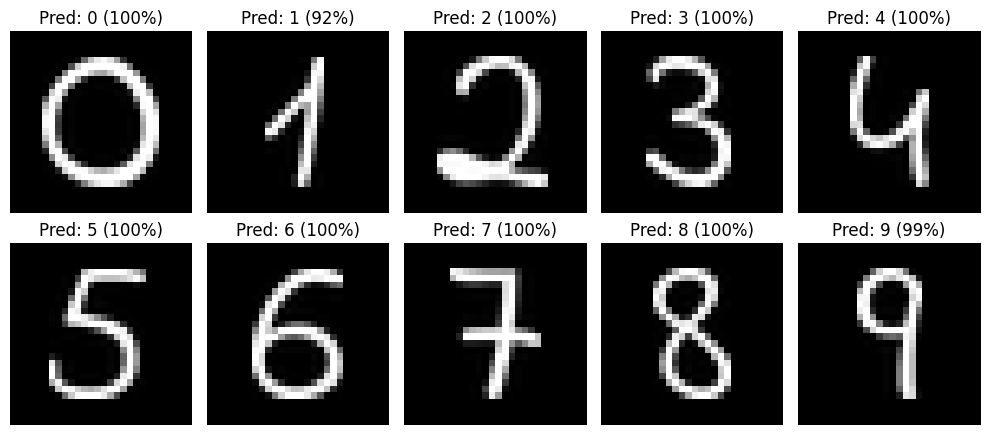

In [7]:
predict_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])


def preprocess(path):
    """Turn a black-on-white digit image into a 28x28 MNIST-style image."""
    img = ImageOps.invert(Image.open(path).convert("L"))
    img = img.point(lambda v: 255 if v > 50 else 0)  # remove faint background noise
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)  # crop to the digit
    scale = 20 / max(img.size)  # longer side -> 20 px
    img = img.resize((max(1, round(img.width * scale)), max(1, round(img.height * scale))), Image.LANCZOS)
    canvas = Image.new("L", (28, 28))  # black 28x28 canvas
    canvas.paste(img, ((28 - img.width) // 2, (28 - img.height) // 2))
    return canvas


def predict_digit(path):
    """Return (predicted digit, confidence, preprocessed image) for an image file."""
    img = preprocess(path)
    img_tensor = predict_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(img_tensor), dim=1)[0]
    confidence, prediction = probs.max(dim=0)
    return prediction.item(), confidence.item(), img


paths = sorted(glob.glob(os.path.join(SAMPLES_DIR, "*.png")))
fig, axes = plt.subplots(2, (len(paths) + 1) // 2, figsize=(2 * ((len(paths) + 1) // 2), 4.5))
for ax, path in zip(axes.flat, paths):
    prediction, confidence, img = predict_digit(path)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {prediction} ({confidence:.0%})")
    ax.axis("off")
    print(f"{os.path.basename(path)}: predicted {prediction} ({confidence:.1%})")
for ax in list(axes.flat)[len(paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Optional: upload an image in Google Colab

If you are running this notebook in Google Colab, uncomment and run the cell below to upload an image
from your computer instead of using the `samples/` folder.

In [8]:
# from google.colab import files
#
# uploaded = files.upload()
# for filename in uploaded:
#     prediction, confidence, img = predict_digit(filename)
#     plt.imshow(img, cmap="gray")
#     plt.title(f"Model Prediction: {prediction} ({confidence:.0%})")
#     plt.axis("off")
#     plt.show()